In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

df = pd.read_csv("ML_input_VST.csv")
df = df.set_index(df.columns[0])
df.index.name = None

df_t = df.T
df_t.index.name = "gene"

df_t.to_csv("transposed_ml_vst.csv")

In [4]:

df = pd.read_csv("/content/transposed_ml_vst.csv")
df = df.set_index(df.columns[0])
df = df.T


In [5]:
y = np.array([0]*18 + [1]*18)
X = df.copy()
X = X.drop(columns=["Y"], errors="ignore")
assert X.shape[0] == len(y), "Mismatch between samples and labels"


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [7]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

In [8]:
rf_params = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(
    rf, rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
rf_grid.fit(X_train_imp, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test_imp)

In [9]:
print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1 Score:", rf_grid.best_score_)

rf_results_df = pd.DataFrame(rf_grid.cv_results_)
rf_results_df.to_csv("rf_all_grid_results.csv", index=False)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV F1 Score: 0.6476190476190476


In [10]:
def evaluate(y_true, y_pred, name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("Sensitivity:", tp / (tp + fn))
    print("Specificity:", tn / (tn + fp))


evaluate(y_test, rf_pred,  "Random Forest")


Random Forest
Accuracy: 0.625
F1 Score: 0.6666666666666666
Sensitivity: 0.75
Specificity: 0.5


In [11]:
genes = X.columns

rf_genes = pd.Series(
    rf_best.feature_importances_,
    index=genes
).sort_values(ascending=False).head(20)


/tmp/ipykernel_2168/64556984.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


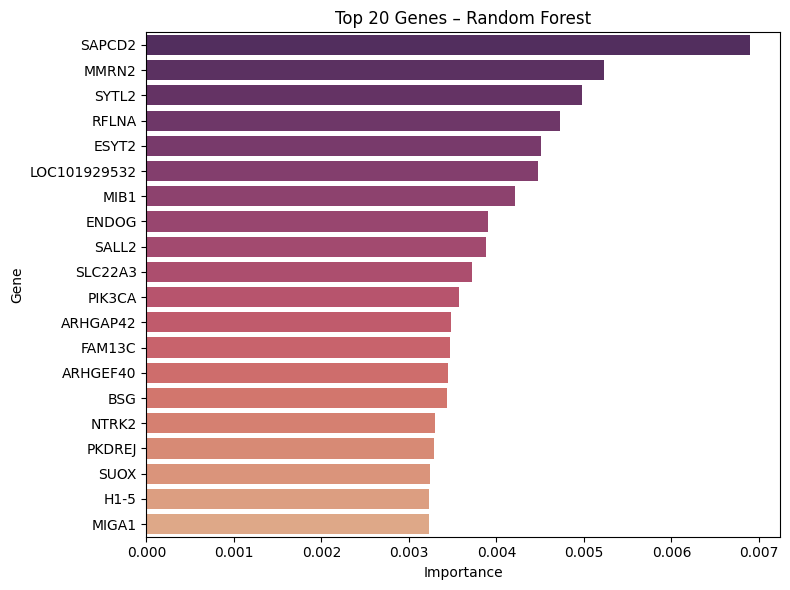

In [12]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x=rf_genes.values,
    y=rf_genes.index,
    palette="flare_r"
)
plt.title("Top 20 Genes – Random Forest")
plt.xlabel("Importance")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
rf_probs = rf_best.predict_proba(X_test_imp)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

In [14]:
print("ROC-AUC Scores:")
print(f"Random Forest AUC: {rf_auc:.3f}")


ROC-AUC Scores:
Random Forest AUC: 0.812


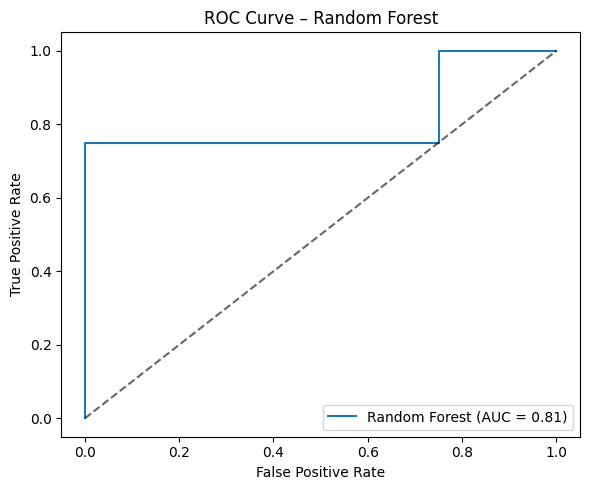

Random Forest ROC-AUC: 0.812


In [15]:
from sklearn.metrics import roc_curve, auc

rf_probs = rf_best.predict_proba(X_test_imp)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(6, 5))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Random Forest ROC-AUC: {rf_auc:.3f}")
